<a href="https://colab.research.google.com/github/GabrielaCordeiro0/GabrielaCordeiro0/blob/main/%F0%9F%92%B3%20Credit%20Card%20Fraud%20Detection%20using%20Machine%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Detecção de Fraude em Cartões de Crédito

#Contexto

Somos um banco digital com 2 milhões de clientes ativos.

Nos últimos 3 meses:

Volume mensal de transações: 35 milhões

Ticket médio: R$210

Taxa de fraude atual: 0,18%

Perda média por fraude confirmada: R$480

Prejuízo mensal estimado: ~R$30 milhões

Nosso modelo atual é antigo e gera muitos falsos positivos, bloqueando cartões legítimos e gerando insatisfação.

#problemas de Negocio
Queremos desenvolver um modelo de detecção de fraude que:

Reduza perdas financeiras

Minimize bloqueios indevidos

Seja interpretável o suficiente para justificar decisões regulatórias

#Dados - Leitura e Analises Iniciais

In [54]:
# 1. Instalação do PySpark no Colab
!pip install pyspark -q

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Inicializar SparkSession
spark = SparkSession.builder.appName("Spark Fraud Detection").getOrCreate()

In [55]:
#carregando o dataset e vendo as primeiras linhas
# Descompactar o arquivo zip para acessar o CSV
!unzip -o /content/creditcard.csv.zip -d /content/

# Carregar o dataset CSV usando Spark
df = spark.read.csv('/content/creditcard.csv', header=True, inferSchema=True)

# Mostra o esquema (tipos de dados) das colunas
df.printSchema()

# Mostra as primeiras 5 linhas de forma organizada
df.show(5)

Archive:  /content/creditcard.csv.zip
  inflating: /content/creditcard.csv  
root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double

In [56]:
# Carregando os dados
DF = pd.read_csv('/content/creditcard.csv .zip', delimiter = ',')
DF.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [57]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [58]:
# Checando se há valores missing
DF.isnull().values.any()

np.False_

In [59]:
# verificando proporção entre classes
class_counts = DF['Class'].value_counts(normalize=True)
class_counts

,proportion
Class,
0,0.998273
1,0.001727


## Separação Treino e Teste - Hold Out Estratificado

Como trata-se de um problema bastante desbalanceado, vamos utilizar a separação de dados em conjuntos de treino e tesde te forma estrtificada.

In [60]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from sklearn.metrics import (precision_recall_curve,
                             PrecisionRecallDisplay)
from sklearn.metrics import confusion_matrix, classification_report

In [61]:
#Separando od dados em treino e teste de forma estratificada
X = DF.drop(columns=['Class'])
y = DF['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [62]:
# Treinando um modelo de Regressão Logística
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
log_reg_model.fit(X_train, y_train)

# Fazendo previsões no conjunto de teste
y_pred_log_reg = log_reg_model.predict(X_test)
y_prob_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


In [63]:


print(confusion_matrix(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg, digits=4))

[[55479  1385]
 [    8    90]]
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



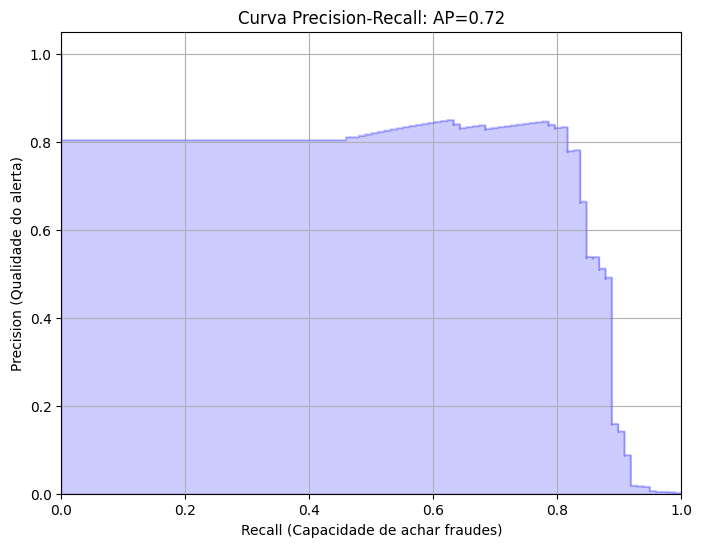

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Pegar as probabilidades da classe 1
y_probs = log_reg_model.predict_proba(X_test)[:, 1]

# 2. Calcular precision e recall para diferentes thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
average_precision = average_precision_score(y_test, y_probs)

# 3. Plotar o gráfico
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')

plt.xlabel('Recall (Capacidade de achar fraudes)')
plt.ylabel('Precision (Qualidade do alerta)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'Curva Precision-Recall: AP={average_precision:.2f}')
plt.grid(True)
plt.show()

In [65]:
# Calcular custo
import numpy as np
from sklearn.metrics import confusion_matrix

costs = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    cost = fn*480 + fp*15
    costs.append(cost)

# Encontrar melhor threshold
best_index = np.argmin(costs)
best_threshold = thresholds[best_index]
best_cost = costs[best_index]

print(f"Melhor threshold: {best_threshold}")
print(f"Menor custo: {best_cost}")

Melhor threshold: 0.9725799198548865
Menor custo: 6630


#Random Forest

In [66]:
#Treinar o modelo

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,           # deixa as árvores crescerem, podemos ajustar depois
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'   # MUITO importante pra desbalanceamento
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [67]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))

[[56861     3]
 [   23    75]]
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9615    0.7653    0.8523        98

    accuracy                         0.9995     56962
   macro avg     0.9806    0.8826    0.9260     56962
weighted avg     0.9995    0.9995    0.9995     56962



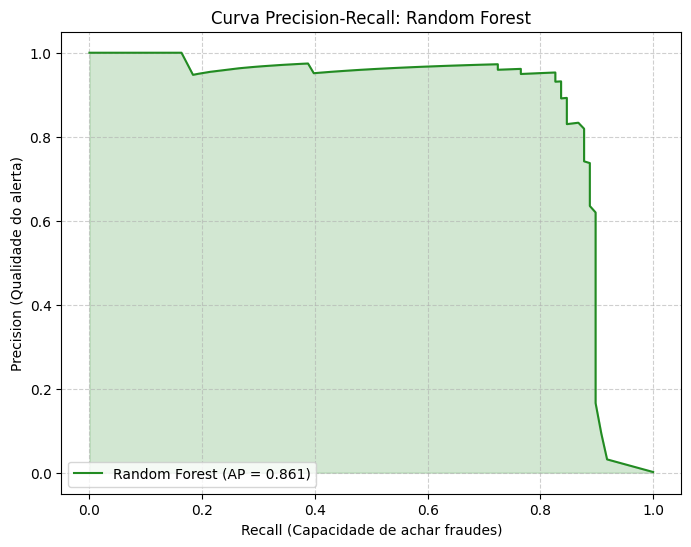

In [68]:
# Resultados_

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Obter probabilidades da classe 1 (Fraude) para o Random Forest
y_probs_rf = rf.predict_proba(X_test)[:, 1]

# 2. Calcular precision, recall e o AP (Average Precision)
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_probs_rf)
ap_rf = average_precision_score(y_test, y_probs_rf)

# 3. Plotar o gráfico
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, color='forestgreen', label=f'Random Forest (AP = {ap_rf:.3f})')
plt.fill_between(recall_rf, precision_rf, alpha=0.2, color='forestgreen')

plt.xlabel('Recall (Capacidade de achar fraudes)')
plt.ylabel('Precision (Qualidade do alerta)')
plt.title('Curva Precision-Recall: Random Forest')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [69]:
# Função de custo
costs_rf = []

for t in thresholds_rf:
    y_pred_t = (y_proba_rf >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    cost = fn*480 + fp*15
    costs_rf.append(cost)

best_idx_rf = np.argmin(costs_rf)
best_threshold_rf = thresholds_rf[best_idx_rf]
best_cost_rf = costs_rf[best_idx_rf]

print(f"Melhor threshold RF: {best_threshold_rf}")
print(f"Menor custo RF: {best_cost_rf}")

Melhor threshold RF: 0.04
Menor custo RF: 5610


#XGBoost

In [70]:
import numpy as np

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 577.2868020304569


In [71]:
#treino
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [72]:
#metas basicas
y_pred_xgb = xgb.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, digits=4))

[[56830    34]
 [   13    85]]
              precision    recall  f1-score   support

           0     0.9998    0.9994    0.9996     56864
           1     0.7143    0.8673    0.7834        98

    accuracy                         0.9992     56962
   macro avg     0.8570    0.9334    0.8915     56962
weighted avg     0.9993    0.9992    0.9992     56962



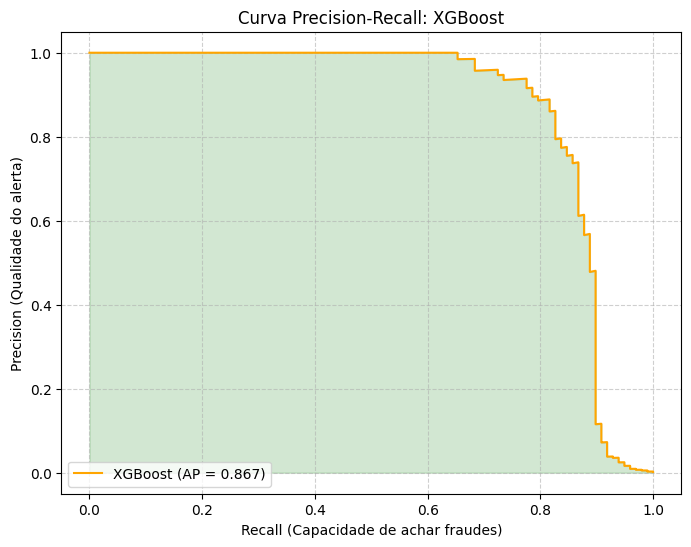

In [73]:
# 1. Obter probabilidades da classe 1 (Fraude) para o XGBoost
y_probs_xgb = xgb.predict_proba(X_test)[:, 1]

# 2. Calcular precision, recall e o AP (Average Precision)
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_probs_xgb)
ap_xgb = average_precision_score(y_test, y_probs_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, color='orange', label=f'XGBoost (AP = {ap_xgb:.3f})')
plt.fill_between(recall_xgb, precision_xgb, alpha=0.2, color='forestgreen')

plt.xlabel('Recall (Capacidade de achar fraudes)')
plt.ylabel('Precision (Qualidade do alerta)')
plt.title('Curva Precision-Recall: XGBoost')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [74]:
# Calcular custo para o XGBoost
costs_xgb = []

for t in thresholds_xgb:
    y_pred_t = (y_probs_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    cost = fn*480 + fp*15
    costs_xgb.append(cost)

best_idx_xgb = np.argmin(costs_xgb)
best_threshold_xgb = thresholds_xgb[best_idx_xgb]
best_cost_xgb = costs_xgb[best_idx_xgb]

print(f"Melhor threshold XGBoost: {best_threshold_xgb}")
print(f"Menor custo XGBoost: {best_cost_xgb}")

Melhor threshold XGBoost: 0.20213113725185394
Menor custo XGBoost: 6225


#Comparacao 3 modelos

In [75]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# 1. Criar uma lista para armazenar os resultados
resultados = []

# Supondo que seus modelos se chamem: modelo_inicial, rf_model, xgb_model
modelos_lista = [
    ("Logistic Regression", log_reg_model),
    ("Random Forest", rf),
    ("XGBoost", xgb)
]

for nome, modelo in modelos_lista:
    # Predições (usando o threshold padrão de 0.5)
    y_pred = modelo.predict(X_test)
    # Probabilidades para o AP
    y_probs = modelo.predict_proba(X_test)[:, 1]

    # Cálculo das métricas
    resultados.append({
        "Modelo": nome,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Average Precision (AP)": average_precision_score(y_test, y_probs)
    })

# 2. Exibir a tabela comparativa
df_comparativo = pd.DataFrame(resultados).set_index("Modelo")
print(df_comparativo.sort_values(by="Average Precision (AP)", ascending=False))

                     Precision    Recall  F1-Score  Average Precision (AP)
Modelo                                                                    
XGBoost               0.714286  0.867347  0.783410                0.867331
Random Forest         0.961538  0.765306  0.852273                0.861023
Logistic Regression   0.061017  0.918367  0.114431                0.715254


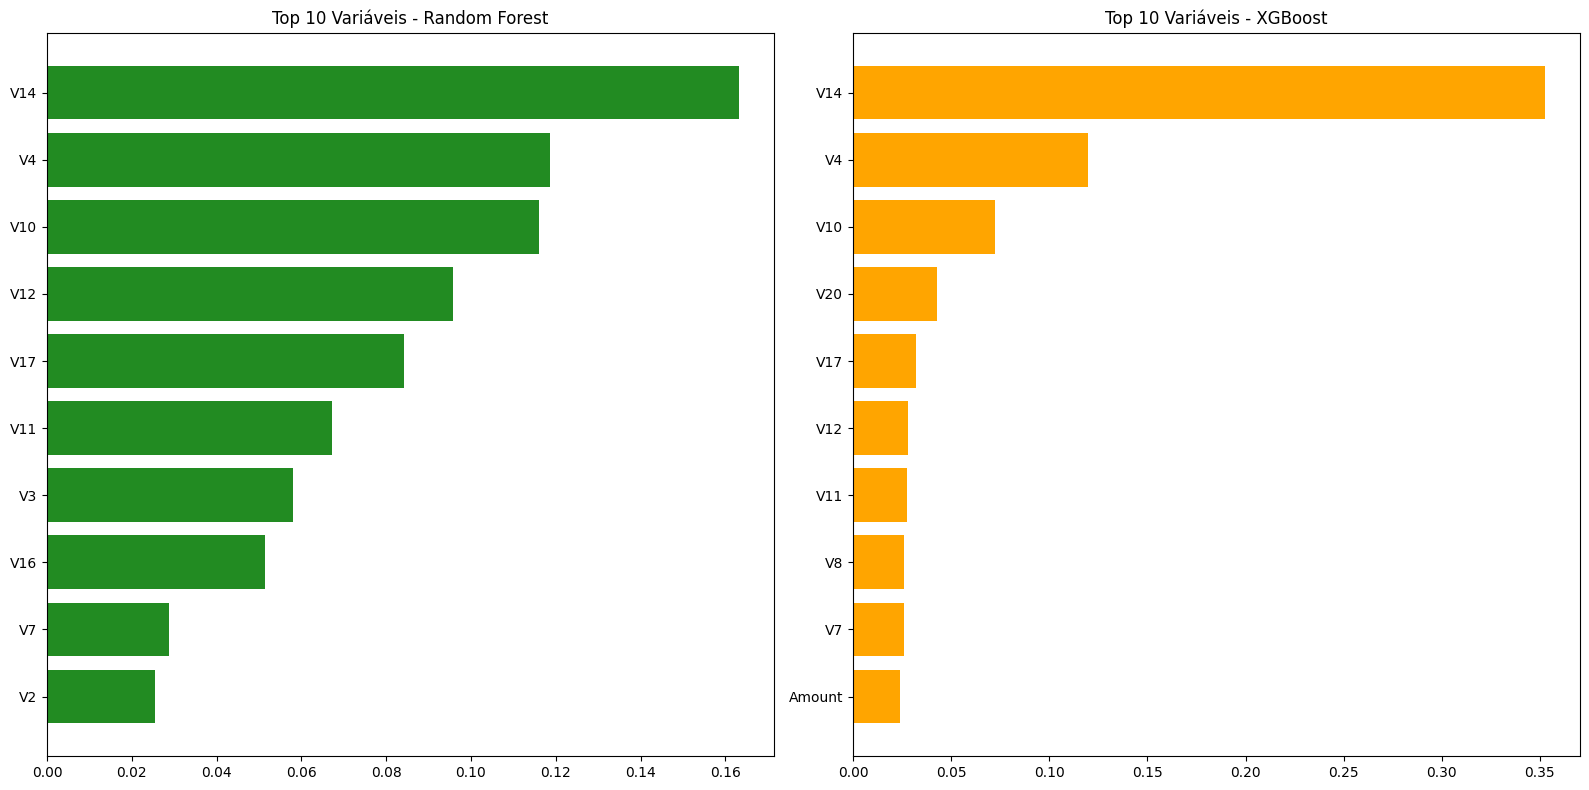

In [76]:
#importância das variáveis
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Criando a figura com dois subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# --- 1. Feature Importance: Random Forest ---
importances_rf = rf.feature_importances_
indices_rf = np.argsort(importances_rf)[-10:] # Top 10
features = X.columns

ax[0].barh(range(len(indices_rf)), importances_rf[indices_rf], color='forestgreen')
ax[0].set_yticks(range(len(indices_rf)))
ax[0].set_yticklabels([features[i] for i in indices_rf])
ax[0].set_title('Top 10 Variáveis - Random Forest')

# --- 2. Feature Importance: XGBoost ---
importances_xgb = xgb.feature_importances_
indices_xgb = np.argsort(importances_xgb)[-10:] # Top 10

ax[1].barh(range(len(indices_xgb)), importances_xgb[indices_xgb], color='orange')
ax[1].set_yticks(range(len(indices_xgb)))
ax[1].set_yticklabels([features[i] for i in indices_xgb])
ax[1].set_title('Top 10 Variáveis - XGBoost')

plt.tight_layout()
plt.show()

## Cross-Validation

In [77]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    xgb, # Usando o modelo XGBoost treinado
    X,
    y,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1
)

print("AP por fold:", scores)
print("AP médio:", np.mean(scores))
print("Desvio padrão:", np.std(scores))

AP por fold: [0.83571431 0.89307943 0.86594549 0.84480671 0.82453684]
AP médio: 0.8528165550305389
Desvio padrão: 0.024289317772275037


#Hiperparametrização

In [78]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 400],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='average_precision',
    cv=skf,
    n_jobs=-1,
    random_state=42
)

# ⚠️ AQUI É O PONTO CRÍTICO:
search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Melhores parâmetros:", search.best_params_)
print("Melhor AP:", search.best_score_)

Melhores parâmetros: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Melhor AP: 0.8531625092946765


## Avaliação - Curva Precision Recall

In [79]:
y_proba = search.best_estimator_.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

print("Average Precision (AP):", ap)

Average Precision (AP): 0.8879631307596242


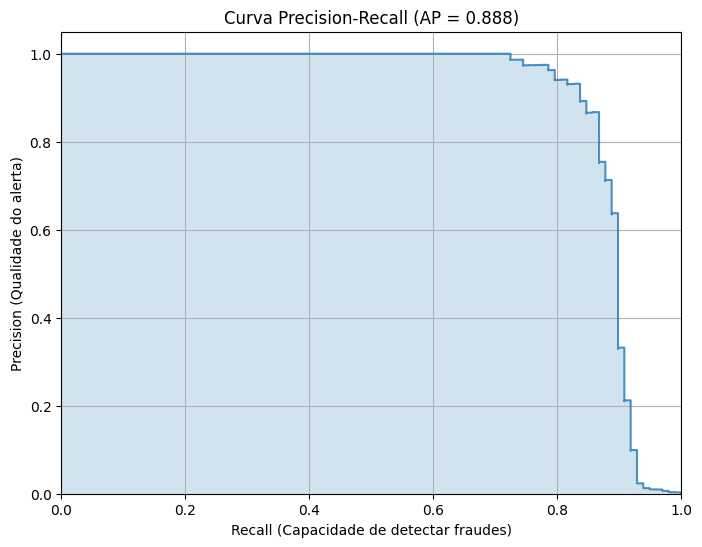

In [80]:
plt.figure(figsize=(8, 6))

plt.step(recall, precision, where='post', alpha=0.8)
plt.fill_between(recall, precision, step='post', alpha=0.2)

plt.xlabel('Recall (Capacidade de detectar fraudes)')
plt.ylabel('Precision (Qualidade do alerta)')
plt.title(f'Curva Precision-Recall (AP = {ap:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)

plt.show()

In [81]:
best_model = search.best_estimator_

In [82]:
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

In [83]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision_tuned, recall_tuned, thresholds_tuned = precision_recall_curve(y_test, y_proba_tuned)
ap_tuned = average_precision_score(y_test, y_proba_tuned)

print("Average Precision (AP) - modelo tunado:", ap_tuned)

Average Precision (AP) - modelo tunado: 0.8879631307596242


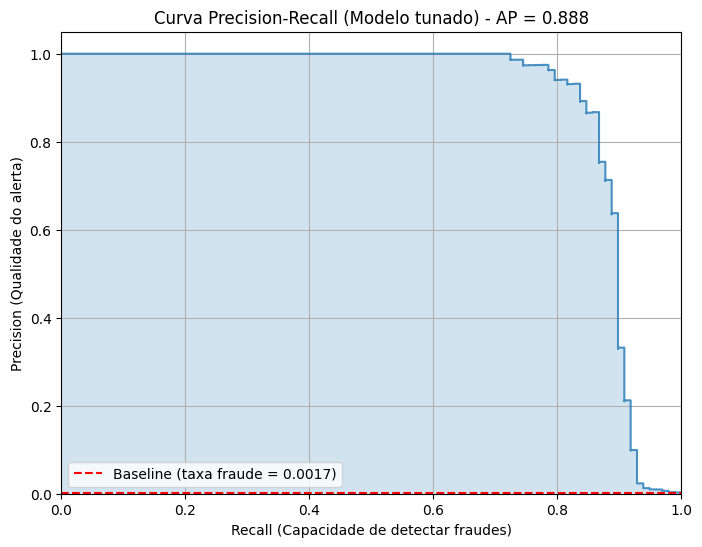

In [84]:
plt.figure(figsize=(8, 6))

plt.step(recall_tuned, precision_tuned, where='post', alpha=0.8)
plt.fill_between(recall_tuned, precision_tuned, step='post', alpha=0.2)

fraud_rate = y_test.mean()
plt.hlines(fraud_rate, 0, 1, colors='red', linestyles='dashed',
           label=f'Baseline (taxa fraude = {fraud_rate:.4f})')

plt.xlabel('Recall (Capacidade de detectar fraudes)')
plt.ylabel('Precision (Qualidade do alerta)')
plt.title(f'Curva Precision-Recall (Modelo tunado) - AP = {ap_tuned:.3f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.legend()
plt.show()

In [85]:
import numpy as np
from sklearn.metrics import confusion_matrix

costs_tuned = []

for t in thresholds_tuned:
    y_pred_t = (y_proba_tuned >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    cost = fn*480 + fp*15   # 480 = fraude, 15 = falso positivo (ajusta se quiser)
    costs_tuned.append(cost)

costs_tuned = np.array(costs_tuned)

best_idx_tuned = np.argmin(costs_tuned)
best_threshold_tuned = thresholds_tuned[best_idx_tuned]
best_cost_tuned = costs_tuned[best_idx_tuned]

print("Melhor threshold (tunado):", best_threshold_tuned)
print("Menor custo (tunado):", best_cost_tuned)

Melhor threshold (tunado): 0.010793641
Menor custo (tunado): 5550


In [86]:
from sklearn.metrics import confusion_matrix, classification_report

t = best_threshold_tuned  # 0.9968911

y_pred_best_tuned = (y_proba_tuned >= t).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best_tuned).ravel()

print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)
print(confusion_matrix(y_test, y_pred_best_tuned))
print(classification_report(y_test, y_pred_best_tuned, digits=4))

TN: 56814 FP: 50 FN: 10 TP: 88
[[56814    50]
 [   10    88]]
              precision    recall  f1-score   support

           0     0.9998    0.9991    0.9995     56864
           1     0.6377    0.8980    0.7458        98

    accuracy                         0.9989     56962
   macro avg     0.8188    0.9485    0.8726     56962
weighted avg     0.9992    0.9989    0.9990     56962



In [87]:
from sklearn.metrics import classification_report

y_pred_best_tuned = (y_proba_tuned >= best_threshold_tuned).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best_tuned).ravel()

print(confusion_matrix(y_test, y_pred_best_tuned))
print(classification_report(y_test, y_pred_best_tuned, digits=4))

print("FN:", fn, "| FP:", fp, "| Custo total:", best_cost_tuned)

[[56814    50]
 [   10    88]]
              precision    recall  f1-score   support

           0     0.9998    0.9991    0.9995     56864
           1     0.6377    0.8980    0.7458        98

    accuracy                         0.9989     56962
   macro avg     0.8188    0.9485    0.8726     56962
weighted avg     0.9992    0.9989    0.9990     56962

FN: 10 | FP: 50 | Custo total: 5550
